<a href="https://colab.research.google.com/github/Bunkhuoch-Ann/Side_Quests_simple/blob/main/Background_remover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

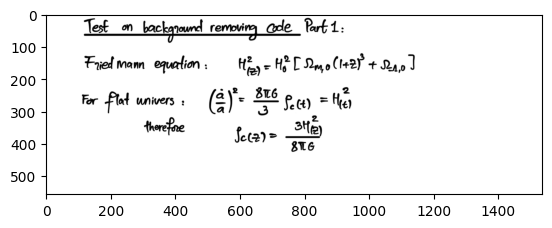

In [9]:
import matplotlib.pyplot as plt
import numpy as np

img_path = '/content/IMG_0797.PNG'

plt.imshow(plt.imread(img_path))
plt.show()

In [10]:
img = plt.imread(img_path)

def remove_background(img, background="white", threshold=0.97):
    """
    background : 'white' or 'black'
    threshold  : how close a pixel must be to the background color
    """
    rgb = img[..., :3].astype(float)

    # matplotlib may load PNG values as 0--255 or 0--1
    if rgb.max() > 1:
        rgb /= 255.0

    if background == "white":
        # Transparent if R, G, and B are all nearly 1
        bg_mask = np.all(rgb >= threshold, axis=-1)

    elif background == "black":
        # Transparent if R, G, and B are all nearly 0
        bg_mask = np.all(rgb <= (1 - threshold), axis=-1)

    else:
        raise ValueError("background must be 'white' or 'black'")

    rgba = np.dstack([rgb, np.ones(rgb.shape[:2])])
    rgba[..., 3] = (~bg_mask).astype(float)   # alpha: 0 = transparent
    return rgba

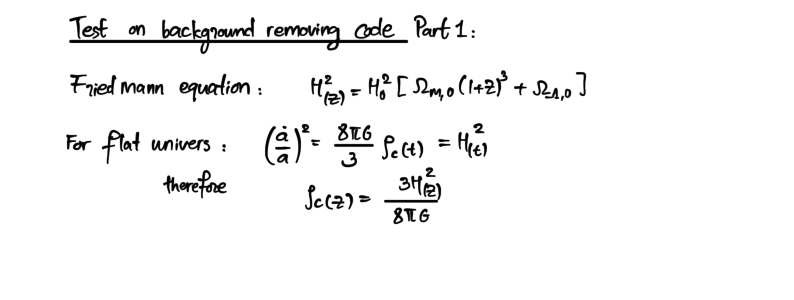

In [15]:
img_no_bg = remove_background(img, background="white", threshold=0.999)

plt.figure(figsize=(10, 8))
plt.imshow(img_no_bg)
plt.gca().set_facecolor("0.7")  # gray makes transparency visible
plt.axis("off")
plt.show()

In [16]:
# img_no_bg_black = remove_background(img, background="black", threshold=0.99)

# plt.figure(figsize=(10, 8))
# plt.imshow(img_no_bg_black)
# plt.gca().set_facecolor("0.7")
# plt.axis("off")
# plt.show()

In [17]:
plt.imsave('/content/IMG_0797_no_background.png', img_no_bg)

**Interactive plot**

In [18]:
# First time to the code use this line and restart the session

# !pip install -q ipympl
# !pip install -q -U plotly anywidget

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# Original image to crop later
img_to_crop = np.asarray(img_no_bg)
height, width = img_to_crop.shape[:2]

# A grayscale preview only; cropping still uses img_no_bg
preview = np.mean(img_to_crop[..., :3], axis=-1)

# Stores coordinates as (x_left, x_right, y_top, y_bottom)
saved_rectangles = []

# Temporary state for the rectangle currently being drawn
clicked_corners = []
current_rectangle = None

fig = go.FigureWidget()

fig.add_trace(
    go.Heatmap(
        z=preview,
        x=np.arange(width),
        y=np.arange(height),
        colorscale="Gray_r",
        showscale=False,
        hoverinfo="none",
    )
)

fig.update_layout(
    width=1000,
    height=800,
    title="Click two opposite corners of a rectangle",
    clickmode="event",
    margin=dict(l=20, r=20, t=60, b=20),
)

fig.update_xaxes(range=[0, width], visible=False)
fig.update_yaxes(
    range=[height, 0],   # image coordinates: y = 0 at the top
    visible=False,
    scaleanchor="x",
)

save_coord_button = widgets.Button(
    description="Save current rectangle coordinates",
    button_style="success",
)

clear_last_button = widgets.Button(
    description="Delete latest saved rectangle",
    button_style="warning",
)

status = widgets.HTML(
    "Click the first corner of a rectangle."
)


def redraw_rectangles():
    """Draw all saved rectangles and the current unsaved one."""
    shapes = []

    # Saved rectangles: green
    for x1, x2, y1, y2 in saved_rectangles:
        shapes.append(
            dict(
                type="rect",
                x0=x1, x1=x2,
                y0=y1, y1=y2,
                line=dict(color="lime", width=3),
                fillcolor="rgba(0,255,0,0.08)",
            )
        )

    # Current rectangle: red
    if current_rectangle is not None:
        x1, x2, y1, y2 = current_rectangle
        shapes.append(
            dict(
                type="rect",
                x0=x1, x1=x2,
                y0=y1, y1=y2,
                line=dict(color="red", width=3),
                fillcolor="rgba(255,0,0,0.08)",
            )
        )

    fig.update_layout(shapes=shapes)


def select_corner(trace, points, selector):
    """Two clicks define one rectangle."""
    global clicked_corners, current_rectangle

    if len(points.xs) == 0:
        return

    x = float(points.xs[0])
    y = float(points.ys[0])

    clicked_corners.append((x, y))

    if len(clicked_corners) == 1:
        status.value = (
            f"First corner: ({x:.0f}, {y:.0f}). "
            "Click the opposite corner."
        )
        return

    # Second click: construct the rectangle
    (x0, y0), (x1, y1) = clicked_corners

    left   = max(0, int(np.floor(min(x0, x1))))
    right  = min(width, int(np.ceil(max(x0, x1))))
    top    = max(0, int(np.floor(min(y0, y1))))
    bottom = min(height, int(np.ceil(max(y0, y1))))

    clicked_corners = []

    if right <= left or bottom <= top:
        current_rectangle = None
        status.value = "Rectangle too small. Click the first corner again."
        redraw_rectangles()
        return

    current_rectangle = (left, right, top, bottom)
    redraw_rectangles()

    status.value = (
        f"Current rectangle: x={left}:{right}, y={top}:{bottom}. "
        "Click <b>Save current rectangle coordinates</b>."
    )


def save_current_rectangle(button):
    global current_rectangle

    if current_rectangle is None:
        status.value = "First define a rectangle using two clicks."
        return

    saved_rectangles.append(current_rectangle)
    current_rectangle = None
    redraw_rectangles()

    status.value = (
        f"Saved rectangle {len(saved_rectangles)} coordinates. "
        "Click two corners to create the next one."
    )

    print("Saved coordinates:", saved_rectangles[-1])


def delete_latest_rectangle(button):
    global current_rectangle, clicked_corners

    # Delete an unfinished red rectangle first
    if current_rectangle is not None:
        current_rectangle = None
        clicked_corners = []
        redraw_rectangles()
        status.value = "Deleted the unfinished rectangle."
        return

    # Otherwise delete the most recently saved green rectangle
    if len(saved_rectangles) == 0:
        status.value = "There is no saved rectangle to delete."
        return

    removed = saved_rectangles.pop()
    redraw_rectangles()

    status.value = (
        f"Deleted latest rectangle: {removed}. "
        f"{len(saved_rectangles)} saved rectangle(s) remain."
    )


fig.data[0].on_click(select_corner)
save_coord_button.on_click(save_current_rectangle)
clear_last_button.on_click(delete_latest_rectangle)

display(widgets.HBox([save_coord_button, clear_last_button]))
display(status)
display(fig)

In [8]:
for i, (x1, x2, y1, y2) in enumerate(saved_rectangles, start=1):
    cropped = img_no_bg[y1:y2, x1:x2]

    output_path = f"/content/nobkg{i}.png"
    plt.imsave(output_path, cropped)

    print(f"Saved {output_path}   shape={cropped.shape}")

Saved /content/nobkg1.png   shape=(79, 403, 4)
Saved /content/nobkg2.png   shape=(61, 321, 4)
Saved /content/nobkg3.png   shape=(120, 310, 4)
Saved /content/nobkg4.png   shape=(105, 590, 4)
